# First Day Quantum Computing Lab

## Understanding Superposition, Measurement, Entanglement, and the Bloch Sphere

This notebook is designed as a **first-day programming activity** for students beginning quantum computing with Qiskit.

### What you will learn
By the end of this lab, you should be able to:
- build a simple quantum circuit
- create a superposition state
- run a circuit on a simulator and interpret measurement counts
- create a basic entangled state
- connect one-qubit states to the **Bloch Sphere**
- explain what common gates such as **H**, **X**, and **Z** do to a qubit

### How to use this notebook
For each section:
1. Read the explanation.
2. Run the code.
3. Answer the short activity questions.
4. Modify the code where asked and observe what changes.


## 1. Setup

The next cell imports the main Qiskit tools used in this notebook.

- `QuantumCircuit` is used to build circuits.
- `AerSimulator` runs the circuit on a simulator.
- `plot_histogram` helps us visualise measurement outcomes.
- `Statevector` lets us examine the state before measurement.
- `plot_bloch_multivector` helps us visualise a single-qubit state on the Bloch Sphere.


In [1]:
import qiskit as qk
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector
import numpy as np
import math

# Uncomment this line if needed in Jupyter
# %matplotlib inline

## 2. Warm-up: a qubit in superposition

A classical bit must be either **0** or **1**.

A qubit can also be in a **superposition** of both basis states.  
One of the easiest ways to create superposition is to apply a **Hadamard gate (`H`)** to \(|0\rangle\).

### What should happen?
If we apply `H` to a qubit that starts in \(|0\rangle\), the state becomes:

\[
\frac{|0\rangle + |1\rangle}{\sqrt{2}}
\]

When measured many times, we expect roughly:
- 50% outcome `0`
- 50% outcome `1`


Circuit:


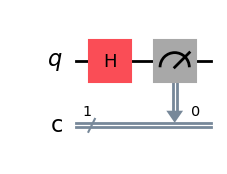

Measurement counts: {'1': 509, '0': 515}


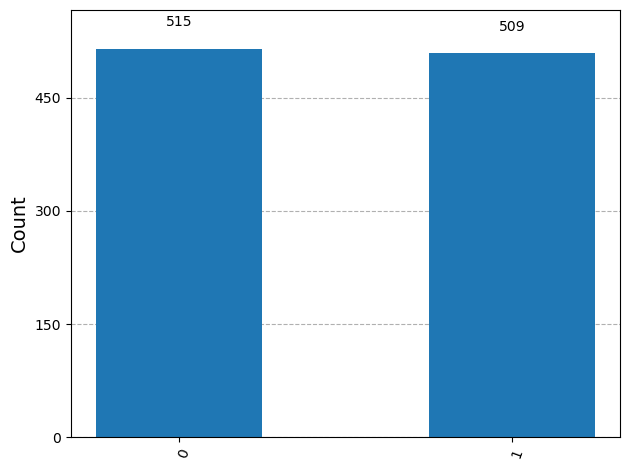

In [4]:
# Example 1: One qubit in superposition
qc1 = QuantumCircuit(1, 1)

# Apply Hadamard gate
qc1.h(0)

# Measure the qubit
qc1.measure(0, 0)

print("Circuit:")
display(qc1.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc1, shots=1024)
result = job.result()
counts = result.get_counts(qc1)

print("Measurement counts:", counts)
plot_histogram(counts)

Circuit:


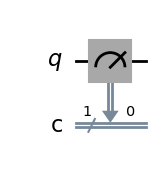

Measurement counts: {'0': 1024}


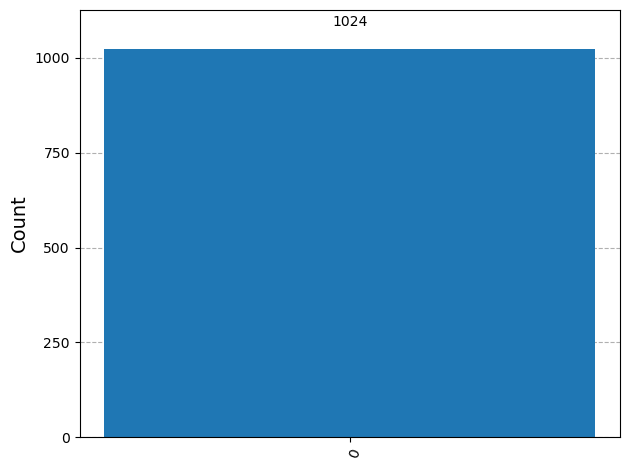

In [5]:
# Example 1: One qubit in superposition
## H gate Removed

qc1 = QuantumCircuit(1, 1)

# Apply Hadamard gate
#qc1.h(0)

# Measure the qubit
qc1.measure(0, 0)

print("Circuit:")
display(qc1.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc1, shots=1024)
result = job.result()
counts = result.get_counts(qc1)

print("Measurement counts:", counts)
plot_histogram(counts)

Circuit:


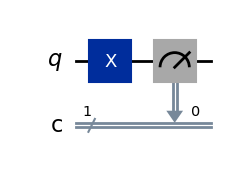

Measurement counts: {'1': 1024}


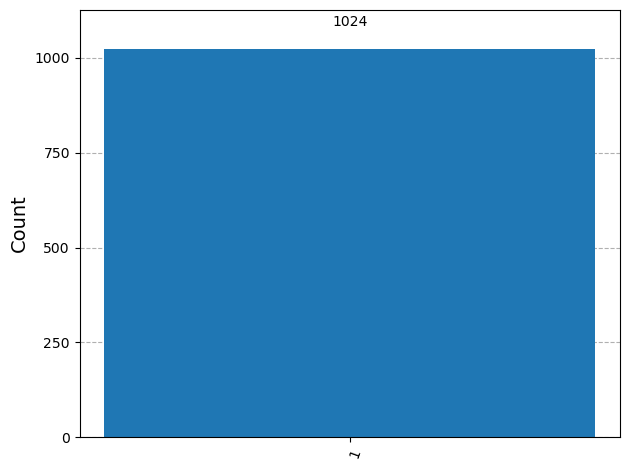

In [6]:
# Example 1: One qubit in superposition
## H gate repalced with X gate 

qc1 = QuantumCircuit(1, 1)

# Apply Hadamard gate
qc1.x(0)

# Measure the qubit
qc1.measure(0, 0)

print("Circuit:")
display(qc1.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc1, shots=1024)
result = job.result()
counts = result.get_counts(qc1)

print("Measurement counts:", counts)
plot_histogram(counts)

### Class activity 1
Answer these questions after running the cell above:

1. Why do we not get only `0` as the result?
2. Are the counts exactly equal? Why or why not?
3. What do you think will happen if the `H` gate is removed?

### Try it yourself
Modify the circuit:
- remove the `H` gate and run again
- replace `qc1.h(0)` with `qc1.x(0)` and run again

Write one sentence explaining each outcome.


## My Answers

1. We don't get only `0` because the Hadamard gate puts the qubit into 
superposition, giving 50% chance of measuring 0 or 1.

2. The counts are not exactly equal even with huge number of shots because of the random noise during the measurement. The noise cancellation circuits before measuring the qbit would yeild better results. 

3. If the H gate is removed, the qubit stays in state |0⟩ and we would 
get only `0` every single time (1024 counts of 0, none of 1).

## Observations
 1. When H gate is removed, the qbit measurement never changed from the initial state |0}.
 2. When the H gate is repalced with X gate, the qbit is flipped |0} to |1} deterministically.
 

## 3. Two qubits in superposition

Now let us extend the idea to **two qubits**.

If we apply a Hadamard gate to both qubits, each qubit goes into superposition independently.  
After measurement, we expect to see four possible outcomes:

- `00`
- `01`
- `10`
- `11`

Each should appear with roughly equal probability.


Circuit:


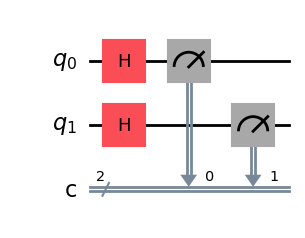

Measurement counts: {'01': 249500, '10': 249669, '11': 250801, '00': 250030}


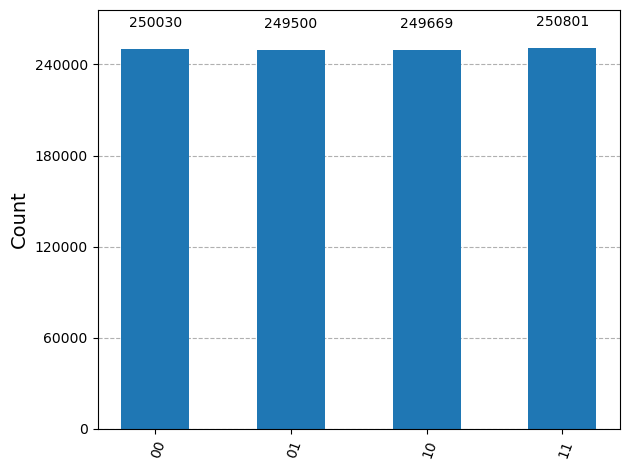

In [14]:
# Example 2: Two qubits in superposition
qc2 = qk.QuantumCircuit(2, 2)

qc2.h(0)
qc2.h(1)

qc2.measure(0, 0)
qc2.measure(1, 1)

print("Circuit:")
display(qc2.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc2, shots=1000000)
result = job.result()
counts = result.get_counts(qc2)

print("Measurement counts:", counts)
plot_histogram(counts)

Circuit:


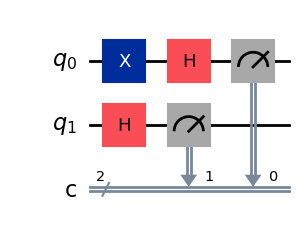

Measurement counts: {'00': 249935, '10': 249323, '11': 250644, '01': 250098}


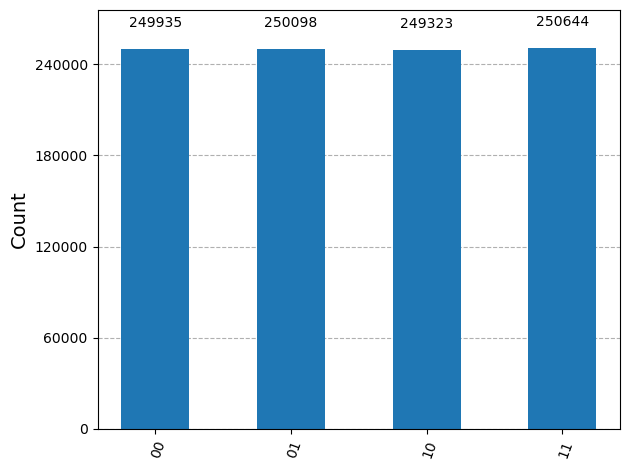

In [11]:
# Example 2: Two qubits in superposition
## X gate on qbit 0 before H gate
qc2 = qk.QuantumCircuit(2, 2)

qc2.x(0)
qc2.h(0)
qc2.h(1)

qc2.measure(0, 0)
qc2.measure(1, 1)

print("Circuit:")
display(qc2.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc2, shots=1000000)
result = job.result()
counts = result.get_counts(qc2)

print("Measurement counts:", counts)
plot_histogram(counts)

Circuit:


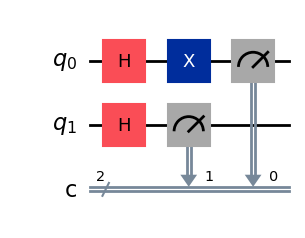

Measurement counts: {'01': 250947, '10': 249701, '11': 249486, '00': 249866}


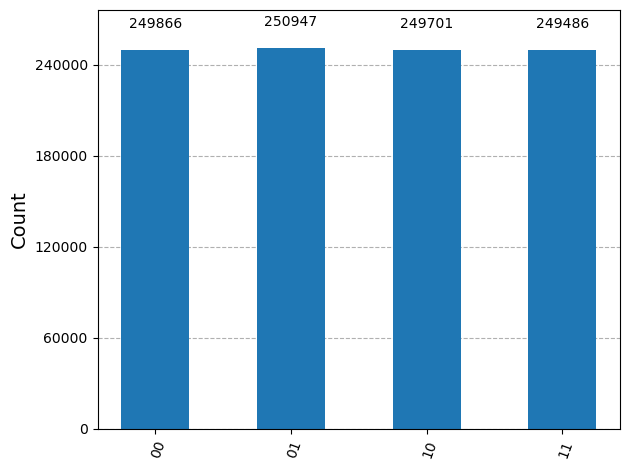

In [9]:
# Example 2: Two qubits in superposition
## X gate on qbit 0 before measurement

qc2 = qk.QuantumCircuit(2, 2)


qc2.h(0)
qc2.x(0)
qc2.h(1)

qc2.measure(0, 0)
qc2.measure(1, 1)

print("Circuit:")
display(qc2.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc2, shots=1000000)
result = job.result()
counts = result.get_counts(qc2)

print("Measurement counts:", counts)
plot_histogram(counts)

Circuit:


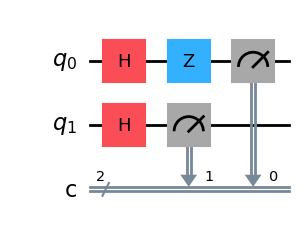

Measurement counts: {'01': 250695, '11': 250220, '00': 248918, '10': 250167}


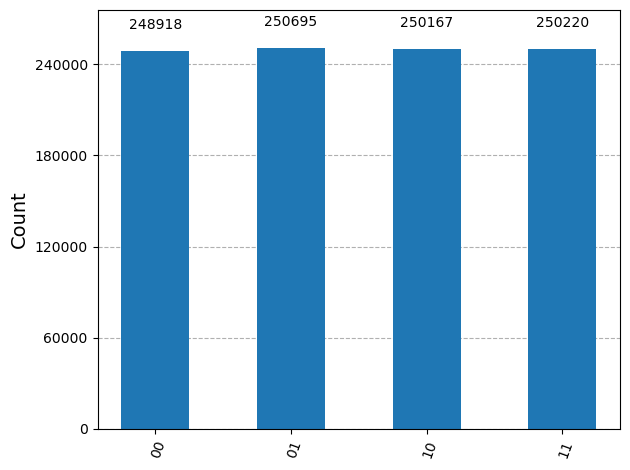

In [10]:
# Example 2: Two qubits in superposition
## Z gate on qbit 0 before measurement

qc2 = qk.QuantumCircuit(2, 2)


qc2.h(0)
qc2.h(1)
qc2.z(0)

qc2.measure(0, 0)
qc2.measure(1, 1)

print("Circuit:")
display(qc2.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc2, shots=1000000)
result = job.result()
counts = result.get_counts(qc2)

print("Measurement counts:", counts)
plot_histogram(counts)

Circuit:


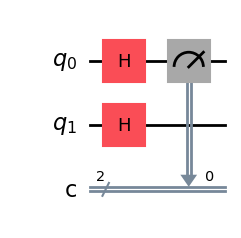

Measurement counts: {'00': 500350, '01': 499650}


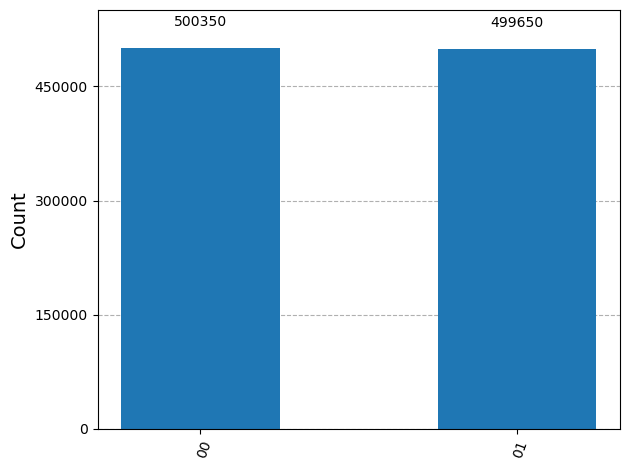

In [15]:
# Example 2: Two qubits in superposition
# measure only one qubit and leave the other unmeasured
qc2 = qk.QuantumCircuit(2, 2)

qc2.h(0)
qc2.h(1)

qc2.measure(0, 0)
#qc2.measure(1, 1)

print("Circuit:")
display(qc2.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc2, shots=1000000)
result = job.result()
counts = result.get_counts(qc2)

print("Measurement counts:", counts)
plot_histogram(counts)

### Class activity 2
Discuss with a partner:

1. Why are there four possible outputs now?
2. Which output appears most often? Is that what you expected?
3. If you apply `X` to qubit 0 before the `H`, how does the result change?

### Extension
Try the following one at a time:
- apply `X` on qubit 0 before measurement
- apply `Z` on qubit 0 before measurement
- measure only one qubit and leave the other unmeasured

What do you observe?


## Discussion
1. With H gate, the possible outcomes for a Q bit are `0` or `1` and in a 2 Qbit circuit each Q bit outcome are independent. Hence there are 4 possible outputs.
2. H gate outputs are with equal chances, but in reality while measuring due to noise there is a possability for unequal outcomes and which is epxected.
3. When an X gate is placed on Q bit (0) before the H gate, the result would remain the same becuase of the H gate superposition state.

## Observations
1. By applying the X gate on qbit 0 before measurement, the output is almost equal for all the outcomes.
2. By applying Z gate on teh qbit 0 before measurement, the output is almost equal for all the outcomes.
3. Measuring only one qbit, the output is 50% chance of 0 or 1.

## 4. Entanglement

Entanglement is one of the most important ideas in quantum computing.

In this section, we create an entangled pair using:
1. a **Hadamard** gate on the first qubit
2. a **CNOT** gate from the first qubit to the second

This creates the Bell state:

\[
\frac{|00\rangle + |11\rangle}{\sqrt{2}}
\]

### What should happen?
When measured many times, the outcomes should be mostly:
- `00`
- `11`

The key point is that the two qubits are **correlated**.


Circuit:


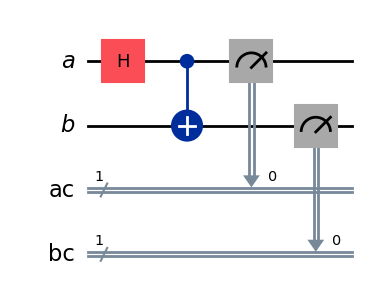

Measurement counts: {'1 1': 1993, '0 0': 2103}


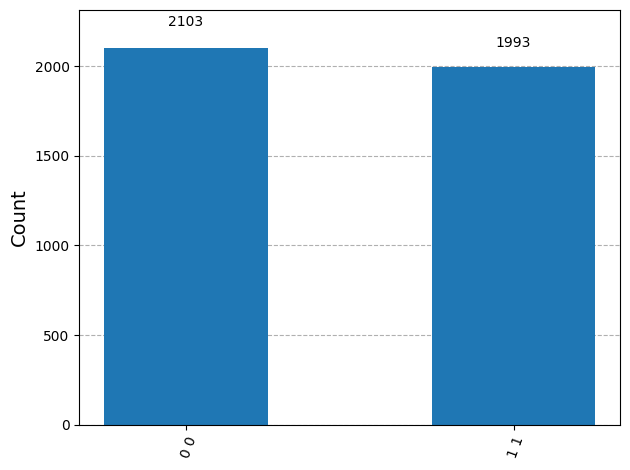

In [4]:
# Example 3: Entangled qubits
a = QuantumRegister(1, name='a')
b = QuantumRegister(1, name='b')
a_c = ClassicalRegister(1, name='ac')
b_c = ClassicalRegister(1, name='bc')

qc3 = QuantumCircuit(a, b, a_c, b_c)

qc3.h(a[0])          # put qubit a into superposition
qc3.cx(a[0], b[0])   # entangle qubit a and qubit b
qc3.measure(a[0], a_c[0])
qc3.measure(b[0], b_c[0])

print("Circuit:")
display(qc3.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc3, shots=4096)
result = job.result()
counts = result.get_counts(qc3)

print("Measurement counts:", counts)
plot_histogram(counts)

Circuit:


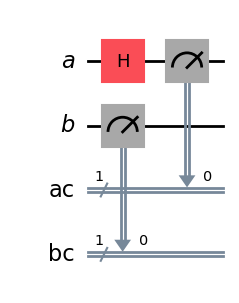

Measurement counts: {'0 0': 2061, '0 1': 2035}


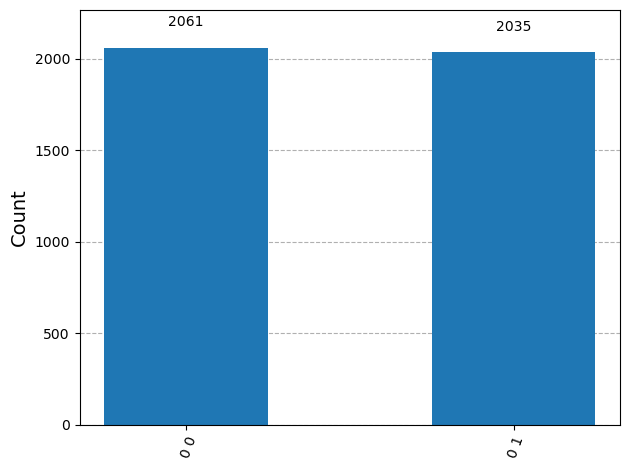

In [17]:
# Example 3: Entangled qubits
# CX gate remomved
a = QuantumRegister(1, name='a')
b = QuantumRegister(1, name='b')
a_c = ClassicalRegister(1, name='ac')
b_c = ClassicalRegister(1, name='bc')

qc3 = QuantumCircuit(a, b, a_c, b_c)

qc3.h(a[0])          # put qubit a into superposition
#qc3.cx(a[0], b[0])   # entangle qubit a and qubit b
qc3.measure(a[0], a_c[0])
qc3.measure(b[0], b_c[0])

print("Circuit:")
display(qc3.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc3, shots=4096)
result = job.result()
counts = result.get_counts(qc3)

print("Measurement counts:", counts)
plot_histogram(counts)

Circuit:


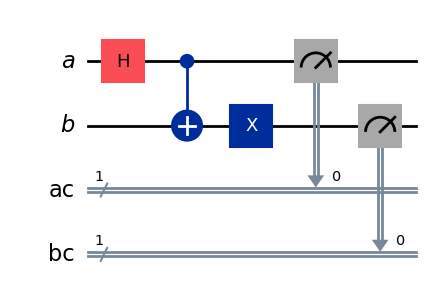

Measurement counts: {'1 0': 2071, '0 1': 2025}


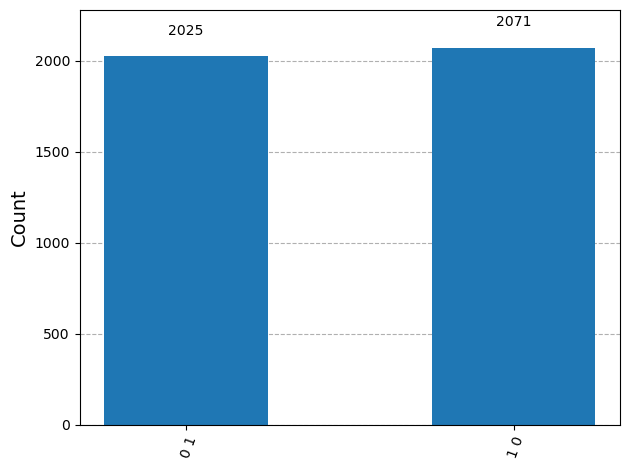

In [21]:
# Example 3: Entangled qubits
# Apply x to qubit b before measurement
a = QuantumRegister(1, name='a')
b = QuantumRegister(1, name='b')
a_c = ClassicalRegister(1, name='ac')
b_c = ClassicalRegister(1, name='bc')

qc3 = QuantumCircuit(a, b, a_c, b_c)

qc3.h(a[0])          # put qubit a into superposition
qc3.cx(a[0], b[0])   # entangle qubit a and qubit b
qc3.x(b[0])
qc3.measure(a[0], a_c[0])
qc3.measure(b[0], b_c[0])

print("Circuit:")
display(qc3.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc3, shots=4096)
result = job.result()
counts = result.get_counts(qc3)

print("Measurement counts:", counts)
plot_histogram(counts)

Circuit:


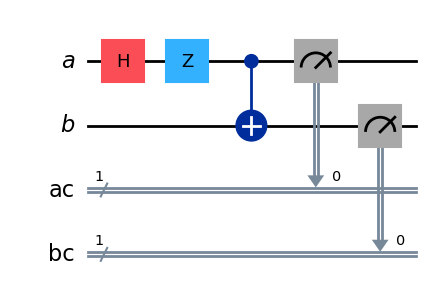

Measurement counts: {'1 1': 2069, '0 0': 2027}


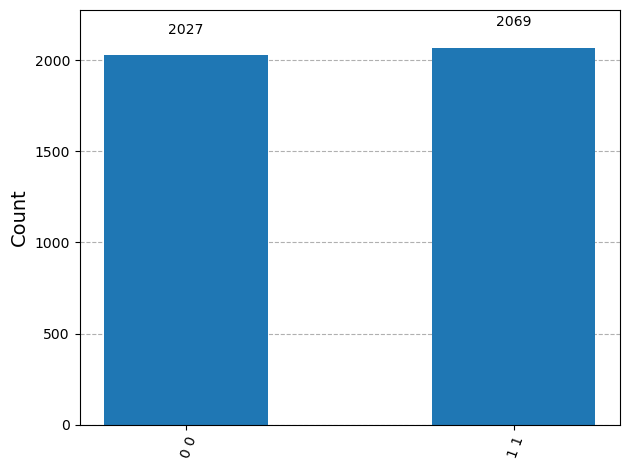

In [22]:
# Example 3: Entangled qubits
# Apply z to qubit a before cx
a = QuantumRegister(1, name='a')
b = QuantumRegister(1, name='b')
a_c = ClassicalRegister(1, name='ac')
b_c = ClassicalRegister(1, name='bc')

qc3 = QuantumCircuit(a, b, a_c, b_c)

qc3.h(a[0])          # put qubit a into superposition
qc3.z(a[0])
qc3.cx(a[0], b[0])   # entangle qubit a and qubit b
qc3.measure(a[0], a_c[0])
qc3.measure(b[0], b_c[0])

print("Circuit:")
display(qc3.draw(output='mpl'))

simulator = AerSimulator()
job = simulator.run(qc3, shots=4096)
result = job.result()
counts = result.get_counts(qc3)

print("Measurement counts:", counts)
plot_histogram(counts)

### Class activity 3
After running the entanglement example, answer:

1. Why do we mainly see `00` and `11`, but not `01` and `10`?
2. How is this different from the earlier two-qubit superposition example?
3. What role does the `cx` gate play?

### Try it yourself
Change the circuit and test:
- remove the `cx` gate
- apply `x` to qubit `b` before measurement
- apply `z` to qubit `a` before the `cx`

Describe what changes in the histogram.


## Answers
1. In Bell State, When Qbit a collapes to 0 the Qbit b will be 0 (CNot gate is inactive) result (0,0) and when the Qbit a is collapsed to 1 the Qbit b is flipped to 1 (CNot gate is active) results (1,1). Hence its always (0,0) or (1,1)
2. In a 2 Qbit circuit, The Bell state output is filtered, while the ealier 2Qbits with H gate's superpostion has the output of all possible outcomes.
3. CX gate flips the state based on the Qbit a collapsed state. If Qbit a collapses to 0, CX gate is inactive, otherwise CX gate is active and flips the Qbit b.

## Changes in the Histogram
1. When cx is removed, the Qbit a is 50% 0 or 1 and Qbit b is always 0. So the possible output are (0,0) and (1,0)
2. When X gate placed on Qbit b before measurement, the only two possible outputs (0,1) or (1,0). anit-Correlated output.
3. When Qbit a collapes to 0, Z gate flips to 1 and activates the Qbit b and it flipped by the CNot gate to 1, results (1,1). When Qbit a collapes to 1, Z gate flips to 0 and CNot is inactive and Qbit b will be 0 and the result is (0,0). Hence its always (0,0) or (1,1).

## 5. Bloch Sphere intuition for a single qubit

The **Bloch Sphere** is a visual way to represent the state of **one qubit**.

### Key reference points
- \(|0\rangle\) is at the **north pole**
- \(|1\rangle\) is at the **south pole**
- superposition states lie at other points on the sphere
- pure states lie on the **surface** of the sphere

You can think of common gates as rotations or flips on this sphere.


Statevector for |0>: Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


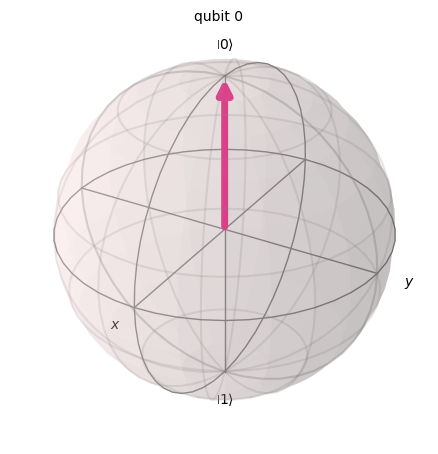

In [23]:
# Bloch Sphere for |0>
qc_b0 = QuantumCircuit(1)
state_b0 = Statevector.from_instruction(qc_b0)

print("Statevector for |0>:", state_b0)
plot_bloch_multivector(state_b0)

Statevector for |1>: Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


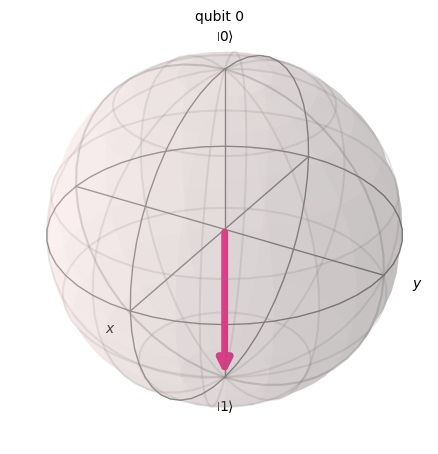

In [6]:
# Bloch Sphere for |1>
qc_b1 = QuantumCircuit(1)
qc_b1.x(0)
state_b1 = Statevector.from_instruction(qc_b1)

print("Statevector for |1>:", state_b1)
plot_bloch_multivector(state_b1)

Statevector for H|0>: Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


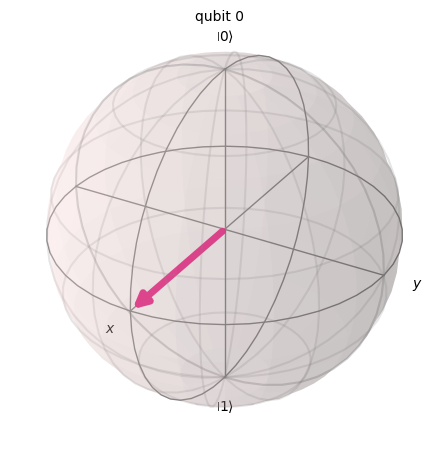

In [7]:
# Bloch Sphere for H|0>
qc_bh = QuantumCircuit(1)
qc_bh.h(0)
state_bh = Statevector.from_instruction(qc_bh)

print("Statevector for H|0>:", state_bh)
plot_bloch_multivector(state_bh)

### Class activity 4
For each state above, identify whether the point is:
- near the north pole
- near the south pole
- on the equator

Then answer:
1. Where is \(|0\rangle\)?
2. Where is \(|1\rangle\)?
3. What type of state is created by `H|0>`?
4. Why is the Bloch Sphere mainly useful for only one qubit?


## 6. Gate effects on the Bloch Sphere

Now let us see how gates move a state around the sphere.

### Predictions before running
Before you run each cell, predict what will happen:
- Will the state flip from top to bottom?
- Will it remain on the equator?
- Will it rotate around an axis?


In [ ]:
# X gate on |0>
qc_x = QuantumCircuit(1)
qc_x.x(0)
state_x = Statevector.from_instruction(qc_x)

print("Statevector after X|0>:", state_x)
plot_bloch_multivector(state_x)

In [ ]:
# Z gate after H
qc_z = QuantumCircuit(1)
qc_z.h(0)
qc_z.z(0)
state_z = Statevector.from_instruction(qc_z)

print("Statevector after ZH|0>:", state_z)
plot_bloch_multivector(state_z)

In [ ]:
# H followed by X
qc_hx = QuantumCircuit(1)
qc_hx.h(0)
qc_hx.x(0)
state_hx = Statevector.from_instruction(qc_hx)

print("Statevector after XH|0>:", state_hx)
plot_bloch_multivector(state_hx)

### Class activity 5
Complete the table below in your notes.

| Circuit | Your prediction | What you observed |
|---|---|---|
| `X|0>` |  |  |
| `ZH|0>` |  |  |
| `XH|0>` |  |  |

Then answer:
1. Which gate produced a clear flip between \(|0\rangle\) and \(|1\rangle\)?
2. Which gate changed the phase of a superposition state?
3. Why can two states give different Bloch positions even when probabilities may look similar?


## 7. Student mini-challenge

Create your own one-qubit circuit using any combination of:
- `h`
- `x`
- `y`
- `z`
- `s`
- `t`

### Your task
1. Build a circuit with at least **two gates**.
2. Predict the Bloch Sphere position before running it.
3. Plot the Bloch Sphere.
4. Write a 3 to 5 line explanation of what happened.

Use the cell below.


In [ ]:
# Student challenge cell
qc_student = QuantumCircuit(1)

# Example: replace these with your own gates
qc_student.h(0)
qc_student.s(0)

print("Your circuit:")
display(qc_student.draw(output='mpl'))

state_student = Statevector.from_instruction(qc_student)
print("Statevector:", state_student)
plot_bloch_multivector(state_student)

## 8. Reflection questions

Write short answers for the following:

1. What is the difference between a classical bit and a qubit?
2. What does the Hadamard gate do?
3. How is an entangled state different from two independent qubits in superposition?
4. What does the Bloch Sphere help us understand?
5. Which part of today's lab did you find the most interesting or confusing?


## 9. Optional assessment task

Submit the following:
- one screenshot of a circuit you created
- one histogram or Bloch Sphere output
- a short explanation of what your circuit does

### Suggested marking focus
- correctness of circuit
- interpretation of results
- ability to connect code with concept
